In [50]:
from typing import TypedDict, Dict  # TypeDict is used to define a dictionary with a fixed structure.
from langgraph.graph import StateGraph, START, END

In [51]:
class AgentState(TypedDict):
    name : str
    age : int
    message : str

def hello_node(state: AgentState)-> AgentState:
    """First node of our sequence"""
    
    state['message'] = 'Hello '+state['name']
    return state

def age_node(state: AgentState)-> AgentState:
    """Second node of our sequence"""
    
    state['message'] = state['message']+f", You are {state['age']} years old."
    return state

In [52]:
graph = StateGraph(AgentState)

graph.add_node('hello', hello_node)
graph.add_node('age', age_node)

graph.set_entry_point('hello')
graph.add_edge('hello', 'age')
graph.set_finish_point('age')

app = graph.compile()

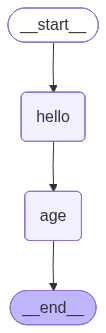

In [53]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [54]:
result = app.invoke({'name': 'Rimon', 'age':20})

In [55]:
result['message']

'Hello Rimon, You are 20 years old.'